In [11]:
# Cargamos las librerias
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import classification_report
from sklearn.neural_network import MLPClassifier


In [12]:
# Cargamos los datos, separamos y normalizamos
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)
X = X / 255.0


In [13]:
# Separamos etiquetads y no etiquetados
n_labeled = 100
X_labeled = X[:n_labeled]
y_labeled = y[:n_labeled]

X_unlabeled = X[n_labeled:]
y_unlabeled = y[n_labeled:]  # las guardamos para evaluar después

y_mixed = np.concatenate([y_labeled, np.full(len(X_unlabeled), -1)])
X_all = np.concatenate([X_labeled, X_unlabeled])

print(f"Total imágenes: {len(X_all)}")
print(f"Etiquetadas: {n_labeled}")
print(f"No etiquetadas: {len(X_unlabeled)}")

Total imágenes: 70000
Etiquetadas: 100
No etiquetadas: 69900


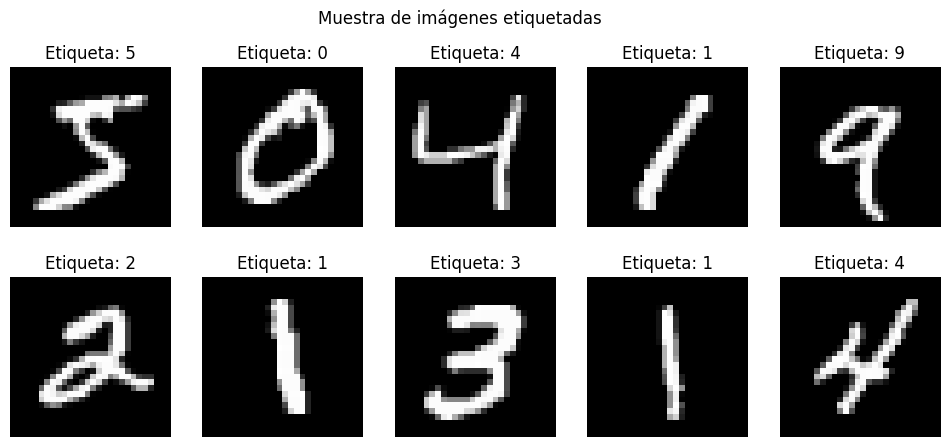

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_labeled[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'Etiqueta: {y_labeled[i]}')
    axes[i].axis('off')

plt.suptitle('Muestra de imágenes etiquetadas')
plt.show()

In [15]:
n_total = 5000
X_lp = X_all[:n_total]
y_lp = y_mixed[:n_total]

# Entrenar Label Propagation
lp = LabelPropagation(kernel='knn', n_neighbors=7, max_iter=10000)
lp.fit(X_lp, y_lp)

# Predecir sobre las no etiquetadas del subconjunto
mask_unlabeled = y_lp == -1
y_pred_lp = lp.transduction_[mask_unlabeled]
y_true_lp = y_unlabeled[:mask_unlabeled.sum()]

print(f"Imágenes no etiquetadas evaluadas: {mask_unlabeled.sum()}")

Imágenes no etiquetadas evaluadas: 4900


In [16]:
# Observamos las metricas
print(classification_report(y_true_lp, y_pred_lp))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95       466
           1       0.54      1.00      0.70       549
           2       0.99      0.26      0.41       482
           3       0.68      0.87      0.76       482
           4       0.91      0.48      0.63       524
           5       0.88      0.50      0.63       429
           6       0.89      0.97      0.93       490
           7       0.92      0.90      0.91       540
           8       0.97      0.70      0.81       454
           9       0.59      0.89      0.71       484

    accuracy                           0.76      4900
   macro avg       0.83      0.75      0.74      4900
weighted avg       0.82      0.76      0.74      4900



In [17]:
# Modelo supervisado
mlp = MLPClassifier(hidden_layer_sizes=(128,), max_iter=500, random_state=42)
mlp.fit(X_labeled, y_labeled)

y_pred_mlp = mlp.predict(X_lp[mask_unlabeled])

print(classification_report(y_true_lp, y_pred_mlp))

=== Supervisado (solo 100 etiquetadas) ===
              precision    recall  f1-score   support

           0       0.81      0.94      0.87       466
           1       0.73      0.95      0.83       549
           2       0.73      0.57      0.64       482
           3       0.71      0.72      0.72       482
           4       0.53      0.89      0.66       524
           5       0.72      0.37      0.49       429
           6       0.86      0.76      0.81       490
           7       0.84      0.67      0.74       540
           8       0.68      0.50      0.58       454
           9       0.47      0.47      0.47       484

    accuracy                           0.69      4900
   macro avg       0.71      0.68      0.68      4900
weighted avg       0.71      0.69      0.68      4900



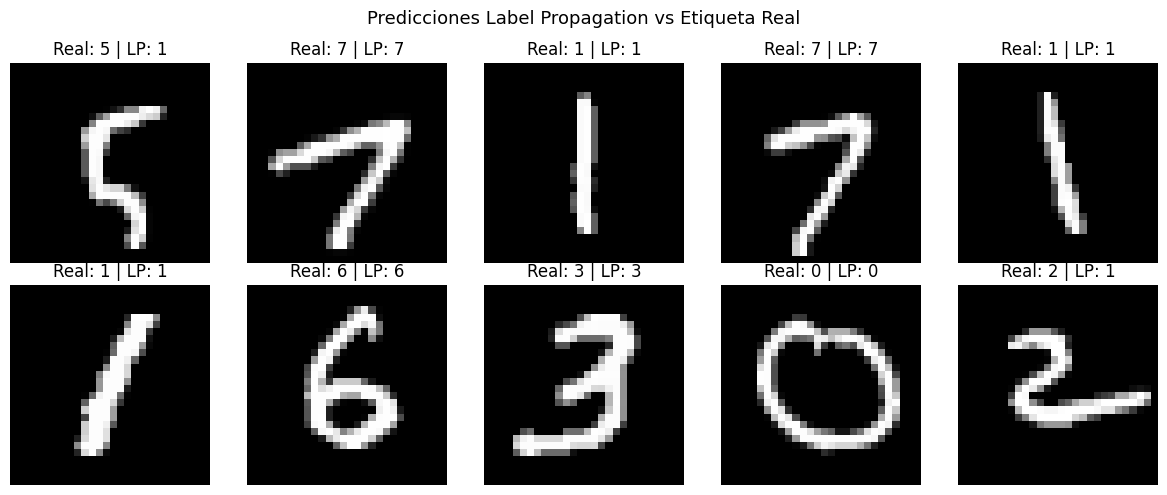

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

X_unlabeled_subset = X_lp[mask_unlabeled]

for i in range(10):
    axes[i].imshow(X_unlabeled_subset[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'Real: {y_true_lp[i]} | LP: {y_pred_lp[i]}')
    axes[i].axis('off')

plt.suptitle('Predicciones Label Propagation vs Etiqueta Real', fontsize=13)
plt.tight_layout()
plt.show()

Acierta 8/10, obteniendo unos resultados coherentes. Observamos  que clasifica incorrectamente el 2.

El aprendizaje semisupervisado es muy útil cuando etiquetar datos es muy costoso o no tienes muchos datos etiquetados. En este ejercicio, con solo 100 imágenes etiquetadas, Label Propagation ha llegado al 76% de accuracy frente al 69% del modelo supervisado usando las mismas 100 etiquetas. O sea, aprovechando los datos no etiquetados hemos ganado una precisión del 7%.

En la vida real esto tiene mucho sentido. Por ejemplo, en medicina con radiografías, necesitaríamos solo algunas etiquetadas y no todas, ya que es costoso, o en empresas con millones de clientes, sería costoso etiquetarlos.
